In [4]:
import pandas as pd

# Usamos read_excel en lugar de read_csv, respetando la mayúscula del archivo
df_airbnb = pd.read_excel("Listing.xlsx")

# Verificamos que cargó mostrando las primeras filas
df_airbnb.head()

,id,listing_url,scrape_id,last_scraped,name,description,neighborhood_overview,picture_url,host_id,host_url,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2818,https://www.airbnb.com/rooms/2818,20210409161549,2021-04-12,Quiet Garden View Room & Super Fast WiFi,Quiet Garden View Room & Super Fast WiFi<br />...,"Indische Buurt (""Indies Neighborhood"") is a ne...",https://a0.muscache.com/pictures/10272854/8dcc...,3159,https://www.airbnb.com/users/show/3159,...,10.0,9.0,10.0,NaN,t,1,0,1,0,1.90
1,20168,https://www.airbnb.com/rooms/20168,20210409161549,2021-04-12,Studio with private bathroom in the centre 1,17th century Dutch townhouse in the heart of t...,Located just in between famous central canals....,https://a0.muscache.com/pictures/69979628/fd6a...,59484,https://www.airbnb.com/users/show/59484,...,10.0,10.0,9.0,0363 CBB3 2C10 0C2A 1E29,t,2,0,2,0,2.50
2,25428,https://www.airbnb.com/rooms/25428,20210409161549,2021-04-11,"Lovely, 1 bed apt in Ctr (w.lift) -3/20-6/20(f...",Lovely apt in Centre ( lift & fireplace) near ...,NaN,https://a0.muscache.com/pictures/138431/7079a9...,56142,https://www.airbnb.com/users/show/56142,...,10.0,10.0,10.0,NaN,f,2,2,0,0,0.13
3,27886,https://www.airbnb.com/rooms/27886,20210409161549,2021-04-11,"Romantic, stylish B&B houseboat in canal district",Stylish and romantic houseboat on fantastic hi...,"Central, quiet, safe, clean and beautiful.",https://a0.muscache.com/pictures/02c2da9d-660e...,97647,https://www.airbnb.com/users/show/97647,...,10.0,10.0,10.0,0363 974D 4986 7411 88D8,t,1,0,1,0,1.94
4,28871,https://www.airbnb.com/rooms/28871,20210409161549,2021-04-13,Comfortable double room,<b>The space</b><br />In a monumental house ri...,"Flower market , Leidseplein , Rembrantsplein",https://a0.muscache.com/pictures/160889/362340...,124245,https://www.airbnb.com/users/show/124245,...,10.0,10.0,10.0,0363 607B EA74 0BD8 2F6F,f,2,0,2,0,2.59


In [5]:
# Con esto listamos todas las columnas para identificar el precio, barrios y habitaciones
print(df_airbnb.columns.tolist())

['id', 'listing_url', 'scrape_id', 'last_scraped', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 

In [6]:
# Listamos los barrios únicos para identificar cómo se escribe el centro de Ámsterdam
print(df_airbnb['neighbourhood_cleansed'].unique().tolist())

['Oostelijk Havengebied - Indische Buurt', 'Centrum-Oost', 'Centrum-West', 'Zuid', 'De Pijp - Rivierenbuurt', 'De Baarsjes - Oud-West', 'Bos en Lommer', 'Oud-Oost', 'Noord-West', 'Westerpark', 'Slotervaart', 'Oud-Noord', 'Watergraafsmeer', 'Geuzenveld - Slotermeer', 'IJburg - Zeeburgereiland', 'Noord-Oost', 'Buitenveldert - Zuidas', 'De Aker - Nieuw Sloten', 'Osdorp', 'Bijlmer-Centrum', 'Gaasperdam - Driemond', 'Bijlmer-Oost']


In [7]:
import scipy.stats as stats

# 1. Filtramos el DataFrame para que solo contenga registros con exactamente 2 habitaciones
df_dos_alcobas = df_airbnb[df_airbnb['bedrooms'] == 2].copy()

# 2. Eliminamos filas donde el precio sea nulo para evitar errores en la prueba
df_dos_alcobas = df_dos_alcobas.dropna(subset=['price'])

# 3. Separamos los precios de las dos zonas del centro
precios_centro_oost = df_dos_alcobas[df_dos_alcobas['neighbourhood_cleansed'] == 'Centrum-Oost']['price']
precios_centro_west = df_dos_alcobas[df_dos_alcobas['neighbourhood_cleansed'] == 'Centrum-West']['price']

# 4. Imprimimos el tamaño de las muestras para verificar los datos
print(f"Cantidad en Centrum-Oost: {len(precios_centro_oost)}")
print(f"Cantidad en Centrum-West: {len(precios_centro_west)}")

Cantidad en Centrum-Oost: 344
Cantidad en Centrum-West: 415


In [13]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Cargamos el archivo
df_airbnb = pd.read_excel("Listing.xlsx")

# Limpiamos los registros que no tengan precio
df_limpio = df_airbnb.dropna(subset=['price']).copy()

In [14]:
# 1. Filtramos los precios globales para las dos zonas del centro
precios_oost_total = df_limpio[df_limpio['neighbourhood_cleansed'] == 'Centrum-Oost']['price']
precios_west_total = df_limpio[df_limpio['neighbourhood_cleansed'] == 'Centrum-West']['price']

print("--- ANÁLISIS DESCRIPTIVO GLOBAL ---")
print(f"Alojamientos en Centrum-Oost: {len(precios_oost_total)} | Promedio: €{precios_oost_total.mean():.2f}")
print(f"Alojamientos en Centrum-West: {len(precios_west_total)} | Promedio: €{precios_west_total.mean():.2f}")
print("-" * 60)

# 2. Ejecutamos el t-test independiente (t de Welch)
t_stat, p_valor_ttest = stats.ttest_ind(precios_oost_total, precios_west_total, equal_var=False)

print("--- RESULTADOS DEL T-TEST ---")
print(f"Estadístico t obtenido: {t_stat:.4f}")
print(f"p-valor obtenido: {p_valor_ttest:.4f}")

--- ANÁLISIS DESCRIPTIVO GLOBAL ---
Alojamientos en Centrum-Oost: 1490 | Promedio: €180.02
Alojamientos en Centrum-West: 1982 | Promedio: €179.63
------------------------------------------------------------
--- RESULTADOS DEL T-TEST ---
Estadístico t obtenido: 0.0647
p-valor obtenido: 0.9484


In [15]:
# 1. Filtramos el DataFrame para trabajar únicamente con los datos del Centro
barrios_centro = ['Centrum-Oost', 'Centrum-West']
df_centro = df_limpio[df_limpio['neighbourhood_cleansed'].isin(barrios_centro)].copy()

# 2. Nos aseguramos de eliminar nulos específicos de la columna property_type
df_centro = df_centro.dropna(subset=['property_type'])

# 3. Ajustamos el modelo lineal y generamos la tabla ANOVA
modelo_anova = ols('price ~ C(property_type)', data=df_centro).fit()
tabla_anova = sm.stats.anova_lm(modelo_anova, typ=2)

print("--- TABLA DE RESULTADOS ANOVA ---")
print(tabla_anova)

--- TABLA DE RESULTADOS ANOVA ---
                        sum_sq      df         F        PR(>F)
C(property_type)  1.118135e+07    46.0  7.306148  3.321104e-43
Residual          1.139484e+08  3425.0       NaN           NaN


<Figure size 800x600 with 0 Axes>

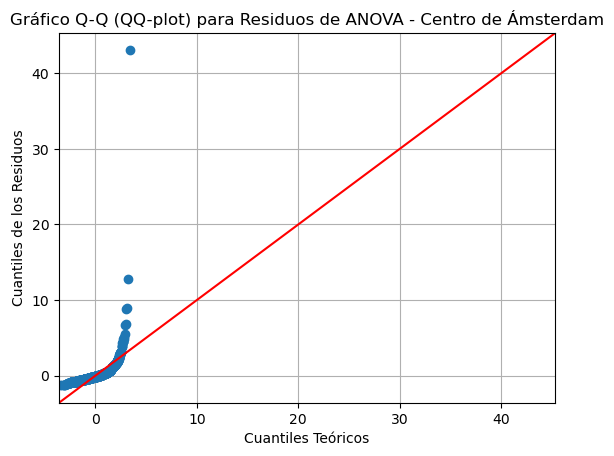

In [16]:
import matplotlib.pyplot as plt

# Extraemos los residuos del modelo ajustado en la celda anterior
residuos = modelo_anova.resid

# Graficamos el QQ-Plot matemático
plt.figure(figsize=(8, 6))
sm.qqplot(residuos, line='45', fit=True)
plt.title('Gráfico Q-Q (QQ-plot) para Residuos de ANOVA - Centro de Ámsterdam')
plt.xlabel('Cuantiles Teóricos')
plt.ylabel('Cuantiles de los Residuos')
plt.grid(True)
plt.show()